In [9]:
import torch
from torchvision.transforms.v2 import RandomHorizontalFlip as rhflip, RandomVerticalFlip as rvflip
import torch.nn as nn
import torch.nn.functional as F
from functools import partial
import matplotlib.pyplot as plt
import scipy.io as io
import sys
import numpy as np
from tqdm import tqdm
import gc

global_path = "/home/ids/edabier/HSU"
sys.path.append(f"{global_path}/HyperSIGMA/HyperspectralUnmixing")
sys.path.append(f"{global_path}/SS-HSU_benchmark")
from mmengine.optim import build_optim_wrapper
from mmcv__custom import custom_layer_decay_optimizer_constructor

from src.utils import utils, losses, plots, extractor
from src.models import models, upsamplers, foundation_models as rsfm, unmixers as unmx

if torch.cuda.is_available():
    dev = "cuda:0"
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
    
elif torch.backends.mps.is_available():
    dev = torch.device("mps")
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
  
else:
    dev = "cpu"
    print(f"Using device: {dev}")

Using device: cuda:0


In [10]:
dataset = "urban"
data = io.loadmat(f"{global_path}/SS-HSU_benchmark/datasets/{dataset}.mat")
Y_flat = torch.tensor(data["Y"], dtype=torch.float)
A_flat = torch.tensor(data["A"], dtype=torch.float)
E_init = torch.tensor(data["E"], dtype=torch.float)
B, c, N = E_init.shape[0], E_init.shape[1], Y_flat.shape[1]

Y_init = utils.oneD_to_2d(Y_flat)
H = Y_init.shape[-1]
A_init = utils.oneD_to_2d(A_flat)
Y_init = Y_init.unsqueeze(0)
Y_init_n = utils.standardise(Y_init)
A_init = A_init.unsqueeze(0)

if dataset == "urban4":
    wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/urban_wavelength.txt"
else:
    wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/{dataset}_wavelength.txt"
with open(wavelengths_path, "r") as file:
    lines = file.readlines()
    wavelengths = [float(line.strip()) for line in lines if line.strip()]

fm_name = "DOFA"
fm, Y_init_f, new_H = rsfm.create_fm(fm_name, Y_init, size="large", version="v1", path=global_path)

_, features = rsfm.extract_f(fm, Y_init, new_H, wavelengths)

D = int(features.shape[0])
alpha = int(features.shape[1]**0.5)

print(f"features: {features.shape}")

features: torch.Size([1024, 196])


In [ ]:
class UnmixingFromFeatures(nn.Module):
    def __init__(self, D, B, c, H=224):
        """
        Upsamples low res features then estimates A_hat
        
        Args:
            D (int): The embed_dim
            B (int): The number of spectral bands in the hsi
            c (int): The number of endmembers to extract
            H (int): The size of the input hsi
            alpha (int): The size of the features
            n_features (int): The size of the list of features in the case of several extracted features

        """
        super(UnmixingFromFeatures, self).__init__()
        self.D = D
        self.B = B
        self.c = c
        self.H = H

        # Upsampling features
        self.upsample = nn.Conv2d(B, D, kernel_size=1)

        # Upsampled features to abundances
        self.abundance_estimator = unmx.Abundance_estimator(self.D, self.c, 1)

        self.smooth = nn.Sequential(
            nn.Conv2d(c, c, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
            nn.Softmax(dim=1),
        )

        self.sum_to_one = unmx.Sum_to_one()
        self.decoder = unmx.Decoder(B=B, c=c)

    @staticmethod
    def weights_init(m):
        if type(m) == nn.Conv2d:
            nn.init.kaiming_normal_(m.weight.data)

    @staticmethod
    def loss(Y_gt, Y_hat, A_hat, E_hat, W_sad=1, W_ab=0.6, W_tv_e=3e-5, W_mse=0.09, hypersigma=False, return_losses=False):
        sad = losses.SADLoss()
        tv = losses.TVLoss(reduction="mean")
        mse = nn.MSELoss(reduction='sum')
        
        loss_sad = W_sad * sad(Y_gt, Y_hat)
        loss_ab = W_ab * torch.sqrt(A_hat).mean()

        if hypersigma:
            loss_mse = W_mse * losses.hypersigma_mse(Y_gt, Y_hat)
        else:
            loss_mse = W_mse * mse(Y_gt, Y_hat)/(torch.norm(Y_gt)**2)

        """Abundances and endmembers regularisation"""
        
        # TV on endmembers (sum of difference between consecutive endmembers)
        loss_tv_e = W_tv_e * (torch.abs(E_hat[:, 1:] - E_hat[:, :-1]).sum())

        """Feature regularisation"""

        loss = loss_sad + loss_ab + loss_tv_e + loss_mse

        if return_losses:
            return loss, loss_sad, loss_ab, loss_tv_e, loss_mse
        else:
            return loss

    def get_abundances(self, Y):

        features_up = self.upsample(Y)
        features_up = features_up.view(
            1, self.D, self.H, self.H
        )
        features_up = (features_up - features_up.mean())/ (1e-8 + features_up.std())
        A_hat = self.abundance_estimator(features_up)
        # A_hat = self.smooth(A_hat)
        A_hat = self.sum_to_one(A_hat)

        return A_hat
    
    def get_endmembers(self):
        return self.decoder.get_endmembers()
    
    def forward(self, Y):
        A_hat = self.get_abundances(Y)
        Y_hat = self.decoder(A_hat)
        E_hat = self.decoder.get_endmembers()

        return E_hat, A_hat, Y_hat

training 1/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.200, NMSE = 0.206
training 2/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.191, NMSE = 0.216
training 3/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.196, NMSE = 0.211
training 4/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.202, NMSE = 0.207
training 5/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.203, NMSE = 0.216
training 6/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Upsampler has 0.166912M params
Average SAD = 0.1984 ± 0.005, NMSE = 0.2114 ± 0.005


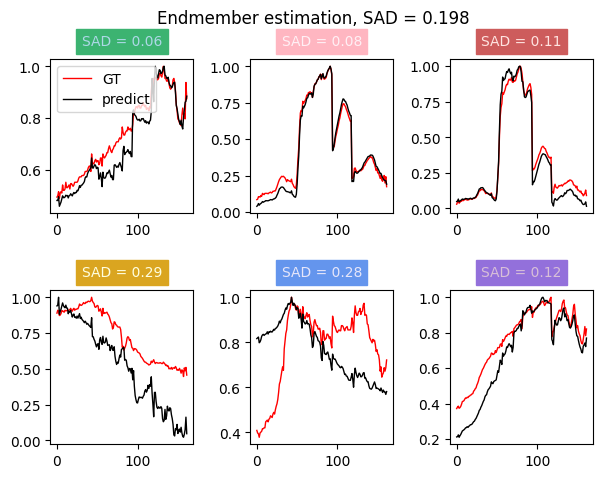

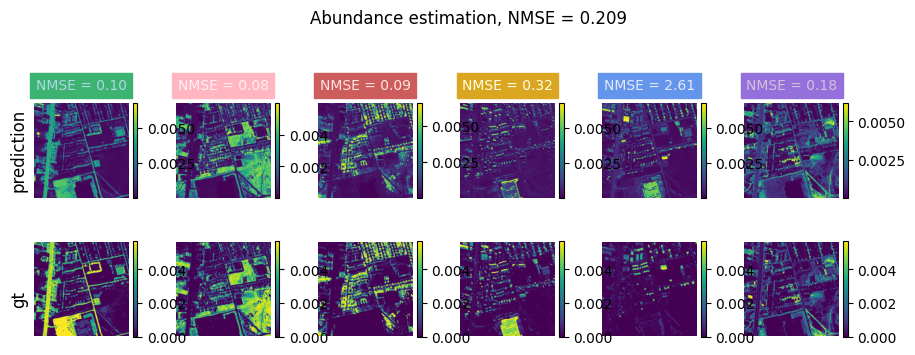

In [13]:
"""Linear upsampling of feature"""

n_xp = 15
mses, sads = [], []
E_hats, A_hats = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, new_H, new_H)
loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)
upsampled_features = torch.zeros(n_xp, D, new_H, new_H)
downsample = nn.AdaptiveAvgPool2d((alpha, alpha))

for i in range(n_xp):
    print(f"training {i+1}/{n_xp}")

    model = UnmixingFromFeatures(D=D, H=new_H, B=B, c=c)
    model.apply(model.weights_init)
    model = models.init_decoder_weights(model, Y_init_f/Y_init_f.max(), c, is_unmixer=True)

    epochs, lr = 200, 0.002
    optim_wrapper = dict(
        optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
        constructor='LayerDecayOptimizerConstructor_ViT',
        paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9, ))
    optimizer = build_optim_wrapper(model, optim_wrapper)

    for _ in range(epochs):

        for Y, _, _ in loader:
        
            optimizer.zero_grad()

            Y = utils.oneD_to_2d(Y).to(dev)

            Y_fm = rsfm.reshape_Y("DOFA", Y, new_H)

            E_hat, A_hat, Y_hat = model(Y_fm)

            loss = model.loss(Y_fm, Y_hat, A_hat, E_hat)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
            optimizer.step()
            
            with torch.no_grad():
                constraints = models.weightConstraint()
                model.decoder.apply(constraints)
                
    model.eval()
    
    with torch.no_grad():
        
        Y_fm, A_init_fm = rsfm.reshape_Y("DOFA", Y, new_H, A_init)
        E_hat, A_hat, _ = model(Y_fm)
        # upsampled_features[i] = model.upsample(features)
        if E_hat.isnan().any():
            break
        sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_init_fm, E_init, normalize_E=True, normalize_A=True, return_results=True, plot_E=False, plot_A=False)
        print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")
        mses.append(mse)
        sads.append(sad)

    E_hats[i] = E_hat
    A_hats[i] = A_hat.squeeze(0)

E_hat_m = torch.nanmean(E_hats, dim=0)
A_hat_m = torch.nanmean(A_hats, dim=0)
sad, _, mse = plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_init_fm, E_init, normalize_E=True, normalize_A=True, return_results=True)
print(f"Upsampler has {sum(p.numel() for p in model.upsample.parameters() if p.requires_grad)/1e6}M params")
print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.4f')} ± {format(torch.std(torch.tensor(sads)), '.3f')}, NMSE = {format(torch.mean(torch.tensor(mses)), '.4f')} ± {format(torch.std(torch.tensor(mses)), '.3f')}")